# Burgers Experiment

This notebook can be used to reproduce the results of section 4.2 and figure 5.
We already provide the experimental data from training runs in the folder
`burgers_data` and `burgers_trj`. In case you want to fully reproduce the
results, delete these folders beforehand.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from burgers_experiment import get_all_data, get_trj

/home/koehler/miniconda3/envs/emu-sup-paper-supplemental/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
configs = [
    {
        "network": network,
        "gamma_2": gamma_2,
        "delta_1": delta_1,
        "num_points": num_points,
        "ic_distribution": ic_distribution,
        "seed_init": seed_init,
        "seed_train": seed_train,
        "seed_test": seed_test,
        "seed_shuffle": seed_shuffle,
    }
    for network in [
        "Conv;34;10;relu",
        "UNet;12;2;relu",  # 27'193 params, 29 receptive field per direction
        "Res;26;8;relu",  # 32'943 params, 16 receptive field per direction
        "FNO;12;18;4;gelu",  # 32'527 params, inf receptive field per direction
        "Dil;2;32;2;relu",  # 31'777 params, 20 receptive field per direction
        "Trans;28;4;4;relu",  # 31'669 params, inf receptive field per direction
    ]
    for (gamma_2, delta_1, num_points, ic_distribution) in [
        (0.2, -8.0, 60, "fourier;1;False;True"),
    ]
    for seed_init in range(0, 30)
    for seed_train in range(100, 100+1)
    for seed_test in range(10_000, 10_000+1)
    for seed_shuffle in range(1_000_000, 1_000_000+1)
]

In [3]:
len(configs)

180

In [4]:
metrics, losses = get_all_data(configs)

  2%|▏         | 4/180 [00:00<00:09, 18.24it/s]

Number of windows: 500, Number of effective epochs: 6400.00, Batches per epoch: 15.62


  3%|▎         | 6/180 [01:04<42:54, 14.80s/it]

Number of windows: 500, Number of effective epochs: 6400.00, Batches per epoch: 15.62


  4%|▍         | 7/180 [02:06<1:16:04, 26.39s/it]

...

 99%|█████████▉| 178/180 [2:33:49<03:08, 94.35s/it]

Number of windows: 500, Number of effective epochs: 6400.00, Batches per epoch: 15.62


 99%|█████████▉| 179/180 [2:35:23<01:34, 94.07s/it]

Number of windows: 500, Number of effective epochs: 6400.00, Batches per epoch: 15.62


100%|██████████| 180/180 [2:36:56<00:00, 52.31s/it]


In [5]:
metrics = pd.concat(metrics).reset_index(drop=True)
losses = pd.concat(losses).reset_index(drop=True)

In [6]:
# facet = sns.relplot(
#     data=losses,
#     x="update_step",
#     y="loss",
#     kind="line",
#     hue="network",
#     estimator="median",
#     # errorbar=("pi", 50),
#     errorbar=None,
# )

# for ax in facet.axes.flat:
#     ax.set_yscale("log")

Recall: Error is against the test simulator, that's why it reaches 1.0 nRMSE already after 10 steps.

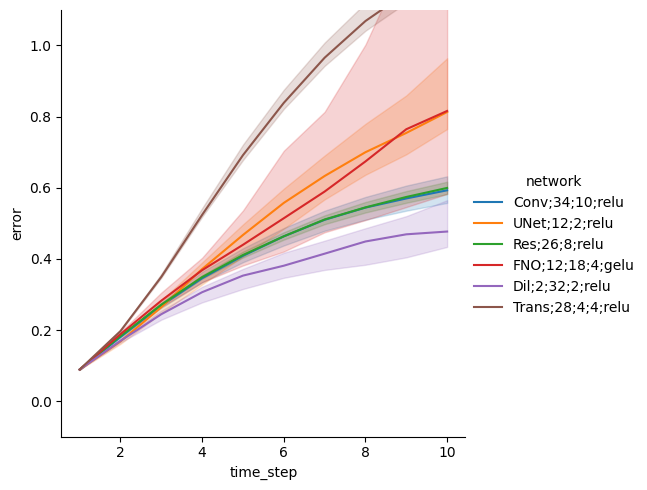

In [7]:
facet = sns.relplot(
    data=metrics.query("time_step <= 100"),
    x="time_step",
    y="error",
    hue="network",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_ylim(-0.1, 1.1)

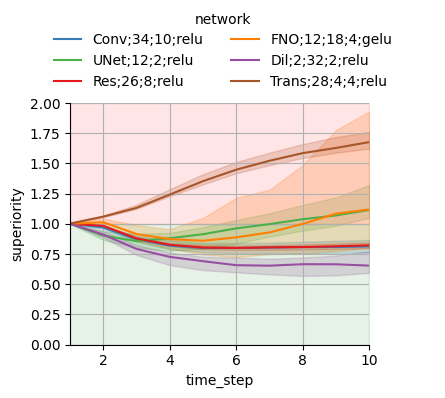

In [8]:
facet = sns.relplot(
    data=metrics.query("time_step <= 10"),
    x="time_step",
    y="superiority",
    hue="network",
    # col="setting",
    kind="line",
    estimator="median",
    errorbar=("pi", 50),
    palette=["#377eb8", "#4daf4a", "#e41a1c", "#ff7f00", "#984ea3", "#a65628"],
    height=4,
)

for ax in facet.axes.flat:
    ax.set_ylim(0.0, 2.0)
    ax.fill_between(
        ax.lines[0].get_xdata(),
        0.0,
        1.0,
        color="green",
        alpha=0.1,
    )
    ax.fill_between(
        ax.lines[0].get_xdata(),
        1.0,
        2.0,
        color="red",
        alpha=0.1,
    )
    ax.set_xlim(1, 10)
    ax.grid()

facet.figure.subplots_adjust(top=0.75)

sns.move_legend(facet, "upper center", ncol=2)

In [9]:
# Assuming the dataframe is named 'metrics' and that 'seed_init', 'seed_train', 'seed_test', 'seed_shuffle' are the seed columns.
# We'll compute the median over all seed columns for each group of the remaining columns.

seed_cols = ["seed_init", "seed_train", "seed_test", "seed_shuffle"]
# Find all columns except the seed columns and the value columns
value_cols = ["superiority", "error"]  # adjust if you want median of other columns
group_cols = [col for col in metrics.columns if col not in seed_cols + value_cols]

# Compute median over seeds for each group
metrics_median = (
    metrics
    .groupby(group_cols, as_index=False)[value_cols]
    .median()
)

# Now metrics_median contains the median over the seeds for each group


In [10]:
median_metrics = metrics.groupby(
    ["network", "time_step"],
).apply(
    lambda x: x[["superiority",]].median(),
    include_groups=False,
)#.reset_index()



In [11]:
median_metrics

superiority
network           time_step             
Conv;34;10;relu   1             0.999949
                  2             0.968975
                  3             0.870132
                  4             0.818509
                  5             0.798724
                  6             0.799329
                  7             0.802886
                  8             0.806398
                  9             0.807392
                  10            0.812208
Dil;2;32;2;relu   1             0.999739
                  2             0.910529
                  3             0.791102
                  4             0.725443
                  5             0.689798
                  6             0.656824
                  7             0.652837
                  8             0.665136
                  9             0.664426
                  10            0.653242
FNO;12;18;4;gelu  1             0.998891
                  2             1.012033
                  3             0.914533
                  4             0.872070
                  5             0.859373
                  6             0.887221
                  7             0.928067
                  8             0.998879
                  9             1.083263
                  10            1.118056
Res;26;8;relu     1             0.999895
                  2             0.982319
                  3             0.877955
                  4             0.826087
                  5             0.802939
                  6             0.799618
                  7             0.804284
                  8             0.807303
                  9             0.813281
                  10            0.821342
Trans;28;4;4;relu 1             1.001052
                  2             1.058807
                  3             1.131240
                  4             1.241196
                  5             1.352412
                  6             1.447394
                  7             1.521111
                  8             1.584263
                  9             1.627203
                  10            1.675598
UNet;12;2;relu    1             0.999775
                  2             0.901955
                  3             0.855764
                  4             0.879784
                  5             0.913362
                  6             0.961689
                  7             0.997006
                  8             1.037365
                  9             1.068540
                  10            1.113852

In [12]:
metrics

,network,gamma_2,delta_1,num_points,ic_distribution,seed_init,seed_train,seed_test,seed_shuffle,superiority,error,time_step
0,Conv;34;10;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,0.999144,0.088368,1
1,Conv;34;10;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,1.059920,0.196982,2
2,Conv;34;10;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,1.039754,0.320873,3
3,Conv;34;10;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,1.022752,0.431432,4
4,Conv;34;10;relu,0.2,-8.0,60,fourier;1;False;True,0,100,10000,1000000,1.019891,0.521428,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1795,Trans;28;4;4;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.449778,0.839907,6
1796,Trans;28;4;4;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.521972,0.965982,7
1797,Trans;28;4;4;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.587437,1.070738,8
1798,Trans;28;4;4;relu,0.2,-8.0,60,fourier;1;False;True,29,100,10000,1000000,1.640530,1.157494,9


In [13]:
superiority_pivoted = metrics.pivot(
    index=["network", "seed_init"],
    columns="time_step",
    values="superiority",
).groupby(
    ["network"],
).apply(
    lambda x: x.median(),
    include_groups=False,
)

In [14]:
superiority_pivoted

time_step,1,2,3,4,5,6,7,8,9,10
network,,,,,,,,,,
Conv;34;10;relu,0.999949,0.968975,0.870132,0.818509,0.798724,0.799329,0.802886,0.806398,0.807392,0.812208
Dil;2;32;2;relu,0.999739,0.910529,0.791102,0.725443,0.689798,0.656824,0.652837,0.665136,0.664426,0.653242
FNO;12;18;4;gelu,0.998891,1.012033,0.914533,0.872070,0.859373,0.887221,0.928067,0.998879,1.083263,1.118056
Res;26;8;relu,0.999895,0.982319,0.877955,0.826087,0.802939,0.799618,0.804284,0.807303,0.813281,0.821342
Trans;28;4;4;relu,1.001052,1.058807,1.131240,1.241196,1.352412,1.447394,1.521111,1.584263,1.627203,1.675598
UNet;12;2;relu,0.999775,0.901955,0.855764,0.879784,0.913362,0.961689,0.997006,1.037365,1.068540,1.113852


In [15]:
# Round to 2 decimal places
superiority_pivoted.round(2)

time_step,1,2,3,4,5,6,7,8,9,10
network,,,,,,,,,,
Conv;34;10;relu,1.0,0.97,0.87,0.82,0.80,0.80,0.80,0.81,0.81,0.81
Dil;2;32;2;relu,1.0,0.91,0.79,0.73,0.69,0.66,0.65,0.67,0.66,0.65
FNO;12;18;4;gelu,1.0,1.01,0.91,0.87,0.86,0.89,0.93,1.00,1.08,1.12
Res;26;8;relu,1.0,0.98,0.88,0.83,0.80,0.80,0.80,0.81,0.81,0.82
Trans;28;4;4;relu,1.0,1.06,1.13,1.24,1.35,1.45,1.52,1.58,1.63,1.68
UNet;12;2;relu,1.0,0.90,0.86,0.88,0.91,0.96,1.00,1.04,1.07,1.11


In [16]:
# Write as Markdown table
print(superiority_pivoted.round(2).to_markdown())

| network           |   1 |    2 |    3 |    4 |    5 |    6 |    7 |    8 |    9 |   10 |
|:------------------|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| Conv;34;10;relu   |   1 | 0.97 | 0.87 | 0.82 | 0.8  | 0.8  | 0.8  | 0.81 | 0.81 | 0.81 |
| Dil;2;32;2;relu   |   1 | 0.91 | 0.79 | 0.73 | 0.69 | 0.66 | 0.65 | 0.67 | 0.66 | 0.65 |
| FNO;12;18;4;gelu  |   1 | 1.01 | 0.91 | 0.87 | 0.86 | 0.89 | 0.93 | 1    | 1.08 | 1.12 |
| Res;26;8;relu     |   1 | 0.98 | 0.88 | 0.83 | 0.8  | 0.8  | 0.8  | 0.81 | 0.81 | 0.82 |
| Trans;28;4;4;relu |   1 | 1.06 | 1.13 | 1.24 | 1.35 | 1.45 | 1.52 | 1.58 | 1.63 | 1.68 |
| UNet;12;2;relu    |   1 | 0.9  | 0.86 | 0.88 | 0.91 | 0.96 | 1    | 1.04 | 1.07 | 1.11 |
